Feature Extraction

In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

DATA_DIR = Path("data")
LETTERS_TRAIN = DATA_DIR / "emnist-letters-train.csv"
LETTERS_MAPPING = DATA_DIR / "emnist-letters-mapping.txt"


def load_emnist_letters(csv_path: Path):
    df = pd.read_csv(csv_path, header=None)
    labels = df.iloc[:, 0].to_numpy(dtype=np.int32)
    images = df.iloc[:, 1:].to_numpy(dtype=np.uint8).reshape(-1, 28, 28)
    return labels, images


def load_letters_mapping(map_path: Path):
    mapping = {}
    with open(map_path, "r", encoding="ascii") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            label = int(parts[0])
            ascii_code = int(parts[-1])
            mapping[label] = chr(ascii_code)
    return mapping


def fix_emnist_orientation(img_28x28):
    # EMNIST is rotated/flipped compared to MNIST
    return np.fliplr(np.rot90(img_28x28, -1))


def binarize(img_28x28, threshold=None):
    if threshold is None:
        threshold = float(img_28x28.mean())
    return (img_28x28 > threshold).astype(np.uint8)


def extract_feature(img_bin):
    row_sum = img_bin.sum(axis=1)
    col_sum = img_bin.sum(axis=0)
    feat = np.concatenate([row_sum, col_sum]).astype(np.float32)
    norm = np.linalg.norm(feat) + 1e-8
    return feat / norm


def remove_small_components(binary_img, min_area=30, connectivity=8):
    binary_mask = (binary_img > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_mask, connectivity=connectivity
    )

    cleaned = np.zeros_like(binary_img, dtype=np.uint8)
    kept_count = 0

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == label] = 255
            kept_count += 1

    return cleaned, kept_count


def preprocess_image(img_path, min_area=15, close_kernel_size=3, use_adaptive=False):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Cannot read image: {img_path}")

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_smooth = cv2.GaussianBlur(img_gray, (3, 3), 0)

    if use_adaptive:
        img_binary = cv2.adaptiveThreshold(
            img_smooth,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31,
            11,
        )
    else:
        _, img_binary = cv2.threshold(
            img_smooth,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU,
        )

    img_binary_inv = 255 - img_binary

    if close_kernel_size and close_kernel_size > 1:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT, (close_kernel_size, close_kernel_size)
        )
        img_closed = cv2.morphologyEx(img_binary_inv, cv2.MORPH_CLOSE, kernel, iterations=1)
    else:
        img_closed = img_binary_inv.copy()

    img_cleaned, kept_count = remove_small_components(
        img_closed, min_area=min_area, connectivity=8
    )

    return {
        "original": img,
        "gray": img_gray,
        "binary": img_binary,
        "cleaned": img_cleaned,
        "removed_small_components": kept_count,
    }


In [32]:
labels, images = load_emnist_letters(LETTERS_TRAIN)
mapping = load_letters_mapping(LETTERS_MAPPING)

letter_features = {}
letter_indices = {}
letter_images = {}

for label, ch in mapping.items():
    idxs = np.where(labels == label)[0]
    if len(idxs) == 0:
        continue
    idx = int(idxs[0])
    img = fix_emnist_orientation(images[idx])
    img_bin = binarize(img)
    letter_features[ch] = extract_feature(img_bin)
    letter_indices[ch] = idx
    letter_images[ch] = img

len(letter_features)


26

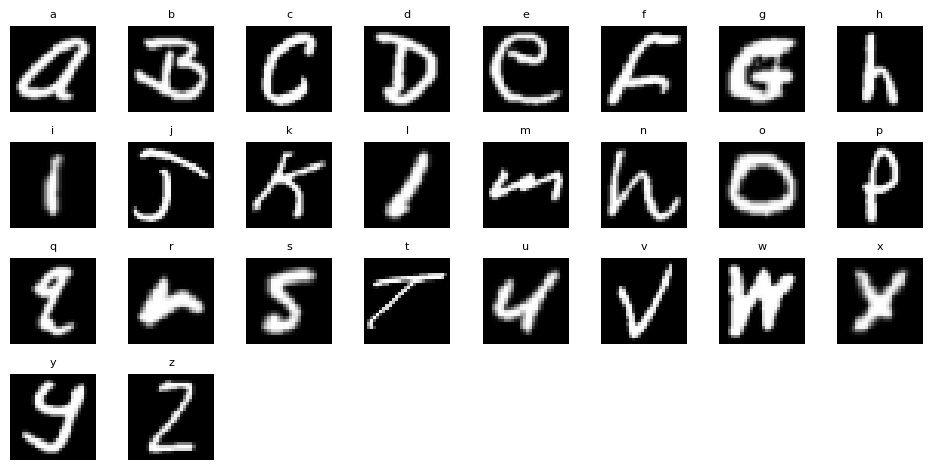

In [ ]:
# Ground truth preview: chon cac ky tu muon so sanh
# Vi du: list("abcxyz") hoac list("abcdefghijklmnopqrstuvwxyz")
if not letter_images:
    raise RuntimeError("letter_images dang rong. Hay chay Cell 2 va Cell 3 truoc.")

# EMNIST letters mapping la chu thuong
all_letters = list("abcdefghijklmnopqrstuvwxyz")
gt_letters = [ch for ch in all_letters if ch in letter_images]
if not gt_letters:
    raise RuntimeError("Khong tim thay ky tu nao trong letter_images.")

cols = 8
rows = int(np.ceil(len(gt_letters) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
axes = np.ravel(axes)

for ax in axes:
    ax.axis("off")

for i, ch in enumerate(gt_letters):
    ax = axes[i]
    img = letter_images[ch]
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{ch}", fontsize=8)
    ax.axis("off")

plt.tight_layout()


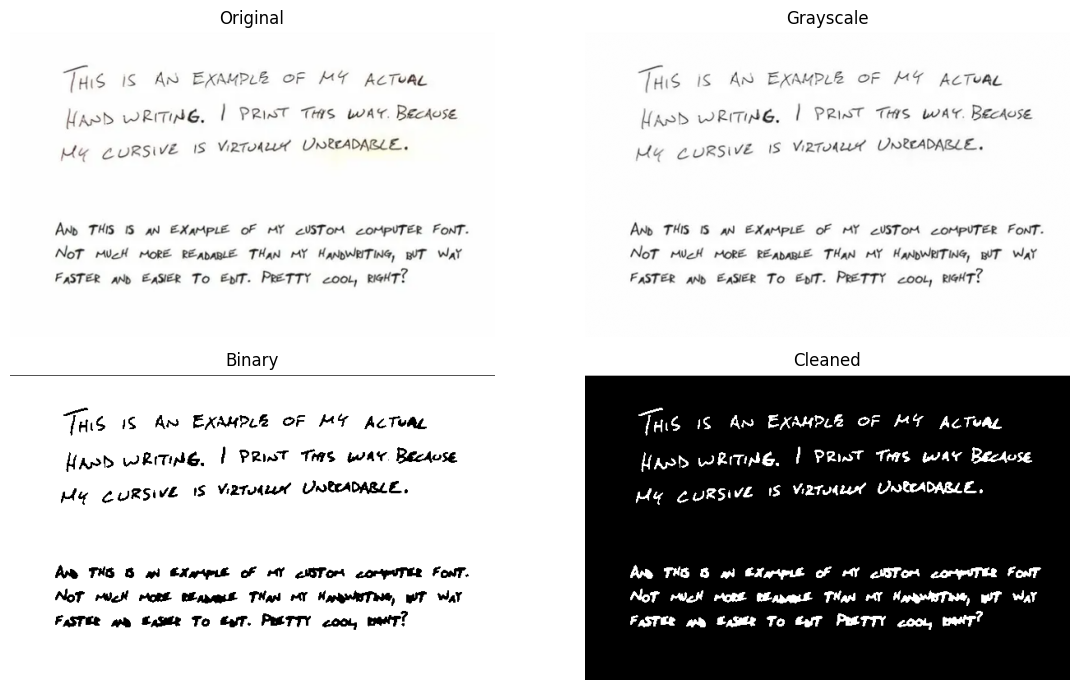

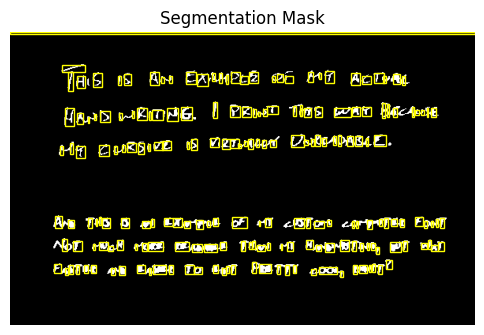

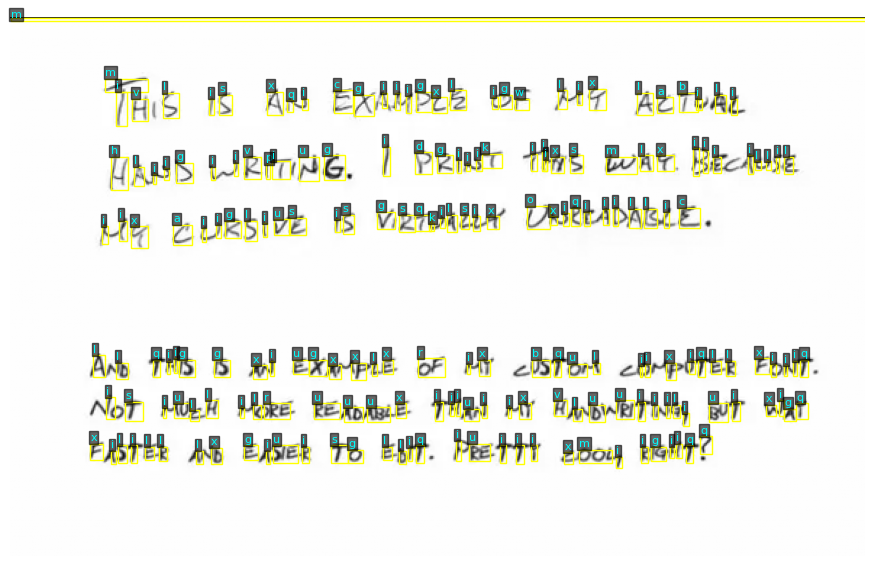

In [34]:
from matplotlib.patches import Rectangle


def sort_boxes_reading_order(boxes):
    if not boxes:
        return []
    heights = [b[3] - b[1] + 1 for b in boxes]
    line_h = max(int(np.median(heights)), 1)
    return sorted(boxes, key=lambda b: (b[1] // line_h, b[0]))


def pad_to_square(img, pad=2, pad_value=0):
    h, w = img.shape
    size = max(h, w)
    out = np.full((size + 2 * pad, size + 2 * pad), pad_value, dtype=img.dtype)
    y = (size - h) // 2 + pad
    x = (size - w) // 2 + pad
    out[y : y + h, x : x + w] = img
    return out


def split_component_by_projection(
    comp,
    x0,
    y0,
    min_col_sum_ratio=0.05,
    valley_ratio=0.6,
    min_width=2,
):
    h, w = comp.shape
    col_sum = (comp > 0).sum(axis=0)
    if col_sum.max() == 0:
        return [(x0, y0, x0 + w - 1, y0 + h - 1)]

    smooth = np.convolve(col_sum, np.ones(3) / 3, mode="same")
    min_col_sum = max(int(h * min_col_sum_ratio), 1)
    valley = max(int(smooth.max() * valley_ratio), min_col_sum)
    active = smooth >= valley

    runs = []
    start = None
    for i, val in enumerate(active):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None
    if start is not None:
        runs.append((start, w - 1))

    if len(runs) <= 1:
        return [(x0, y0, x0 + w - 1, y0 + h - 1)]

    boxes = []
    for cs, ce in runs:
        if ce - cs + 1 < min_width:
            continue
        sub = comp[:, cs : ce + 1]
        ys, xs = np.where(sub > 0)
        if ys.size == 0:
            continue
        yy0 = y0 + ys.min()
        yy1 = y0 + ys.max()
        xx0 = x0 + cs + xs.min()
        xx1 = x0 + cs + xs.max()
        boxes.append((xx0, yy0, xx1, yy1))

    if not boxes:
        return [(x0, y0, x0 + w - 1, y0 + h - 1)]

    return boxes


def segment_characters_by_projection(
    cleaned,
    min_area=15,
    open_kernel_size=1,
    erode_iter=1,
    erode_kernel=(1, 2),
    split_ratio=1.1,
    min_col_sum_ratio=0.05,
    valley_ratio=0.6,
    min_width=2,
):
    seg = cleaned.copy()
    if open_kernel_size and open_kernel_size > 1:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT, (open_kernel_size, open_kernel_size)
        )
        seg = cv2.morphologyEx(seg, cv2.MORPH_OPEN, kernel, iterations=1)

    if erode_iter and erode_iter > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, erode_kernel)
        seg = cv2.erode(seg, kernel, iterations=erode_iter)

    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(
        (seg > 0).astype(np.uint8), connectivity=8
    )

    boxes = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area < min_area:
            continue
        if w >= split_ratio * h and w >= 10:
            comp = seg[y : y + h, x : x + w]
            boxes.extend(
                split_component_by_projection(
                    comp,
                    x,
                    y,
                    min_col_sum_ratio=min_col_sum_ratio,
                    valley_ratio=valley_ratio,
                    min_width=min_width,
                )
            )
        else:
            boxes.append((x, y, x + w - 1, y + h - 1))

    return seg, sort_boxes_reading_order(boxes)


page_path = Path("test_image.png")  # change to your text image
min_area = 12
close_kernel_size = 1
use_adaptive = False

# Projection split params
min_area_cc = 20
open_kernel_size = 1
erode_iter = 1
erode_kernel = (1, 2)
split_ratio = 1.1
min_col_sum_ratio = 0.05
valley_ratio = 0.6
min_width = 2

show_boxes_on_seg = True

if page_path.exists():
    pre = preprocess_image(
        page_path,
        min_area=min_area,
        close_kernel_size=close_kernel_size,
        use_adaptive=use_adaptive,
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes[0, 0].imshow(cv2.cvtColor(pre["original"], cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("Original")
    axes[0, 1].imshow(pre["gray"], cmap="gray")
    axes[0, 1].set_title("Grayscale")
    axes[1, 0].imshow(pre["binary"], cmap="gray")
    axes[1, 0].set_title("Binary")
    axes[1, 1].imshow(pre["cleaned"], cmap="gray")
    axes[1, 1].set_title("Cleaned")
    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    cleaned = pre["cleaned"]
    seg, boxes = segment_characters_by_projection(
        cleaned,
        min_area=min_area_cc,
        open_kernel_size=open_kernel_size,
        erode_iter=erode_iter,
        erode_kernel=erode_kernel,
        split_ratio=split_ratio,
        min_col_sum_ratio=min_col_sum_ratio,
        valley_ratio=valley_ratio,
        min_width=min_width,
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(seg, cmap="gray")
    ax.set_title("Segmentation Mask")
    if show_boxes_on_seg:
        for (x0, y0, x1, y1) in boxes:
            ax.add_patch(
                Rectangle(
                    (x0, y0), x1 - x0 + 1, y1 - y0 + 1, fill=False, edgecolor="yellow", linewidth=1
                )
            )
    ax.axis("off")
    plt.show()

    preds = []
    for (x0, y0, x1, y1) in boxes:
        crop = cleaned[y0 : y1 + 1, x0 : x1 + 1]
        crop = pad_to_square(crop, pad=2, pad_value=0)
        crop = cv2.resize(crop, (28, 28), interpolation=cv2.INTER_NEAREST)
        crop_bin = (crop > 0).astype(np.uint8)

        feat = extract_feature(crop_bin)
        scores = {ch: float(np.dot(feat, f)) for ch, f in letter_features.items()}
        best = max(scores, key=scores.get)
        preds.append((x0, y0, x1, y1, best, scores[best]))

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(pre["gray"], cmap="gray")
    for (x0, y0, x1, y1, best, score) in preds:
        ax.add_patch(
            Rectangle(
                (x0, y0), x1 - x0 + 1, y1 - y0 + 1, fill=False, edgecolor="yellow", linewidth=1
            )
        )
        ax.text(
            x0,
            max(y0 - 2, 0),
            best,
            color="cyan",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.6, pad=1),
        )

    ax.axis("off")
    plt.show()
else:
    print("Khong tim thay anh, hay doi page_path.")
